# Trees & Cluster Trees - Embedding Visualisation

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap
import numpy as np


from vis import (
    Plotter,
    _window_and_filter,
    load_embeddings_pt,
    load_embeddings_batch,
)

CTX_LENS = [300, 600, 1200, 1800]
VOCAB_PATH  = Path("../data/uncorrelated-words/selected_llama31_layer0.txt")


/home/gluc/Desktop/nlp/hico/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Binary Tree (4 levels)

In [2]:
STRUCT_PATH = Path("../data/one_random_walk/tree_4_levels/bin_tree_structure.txt")
EMB_DIR     = Path("../embeddings/one_random_walk/tree_4_levels")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

### PCA 2D

  [] Discarded 2/301 embeddings with unknown token IDs


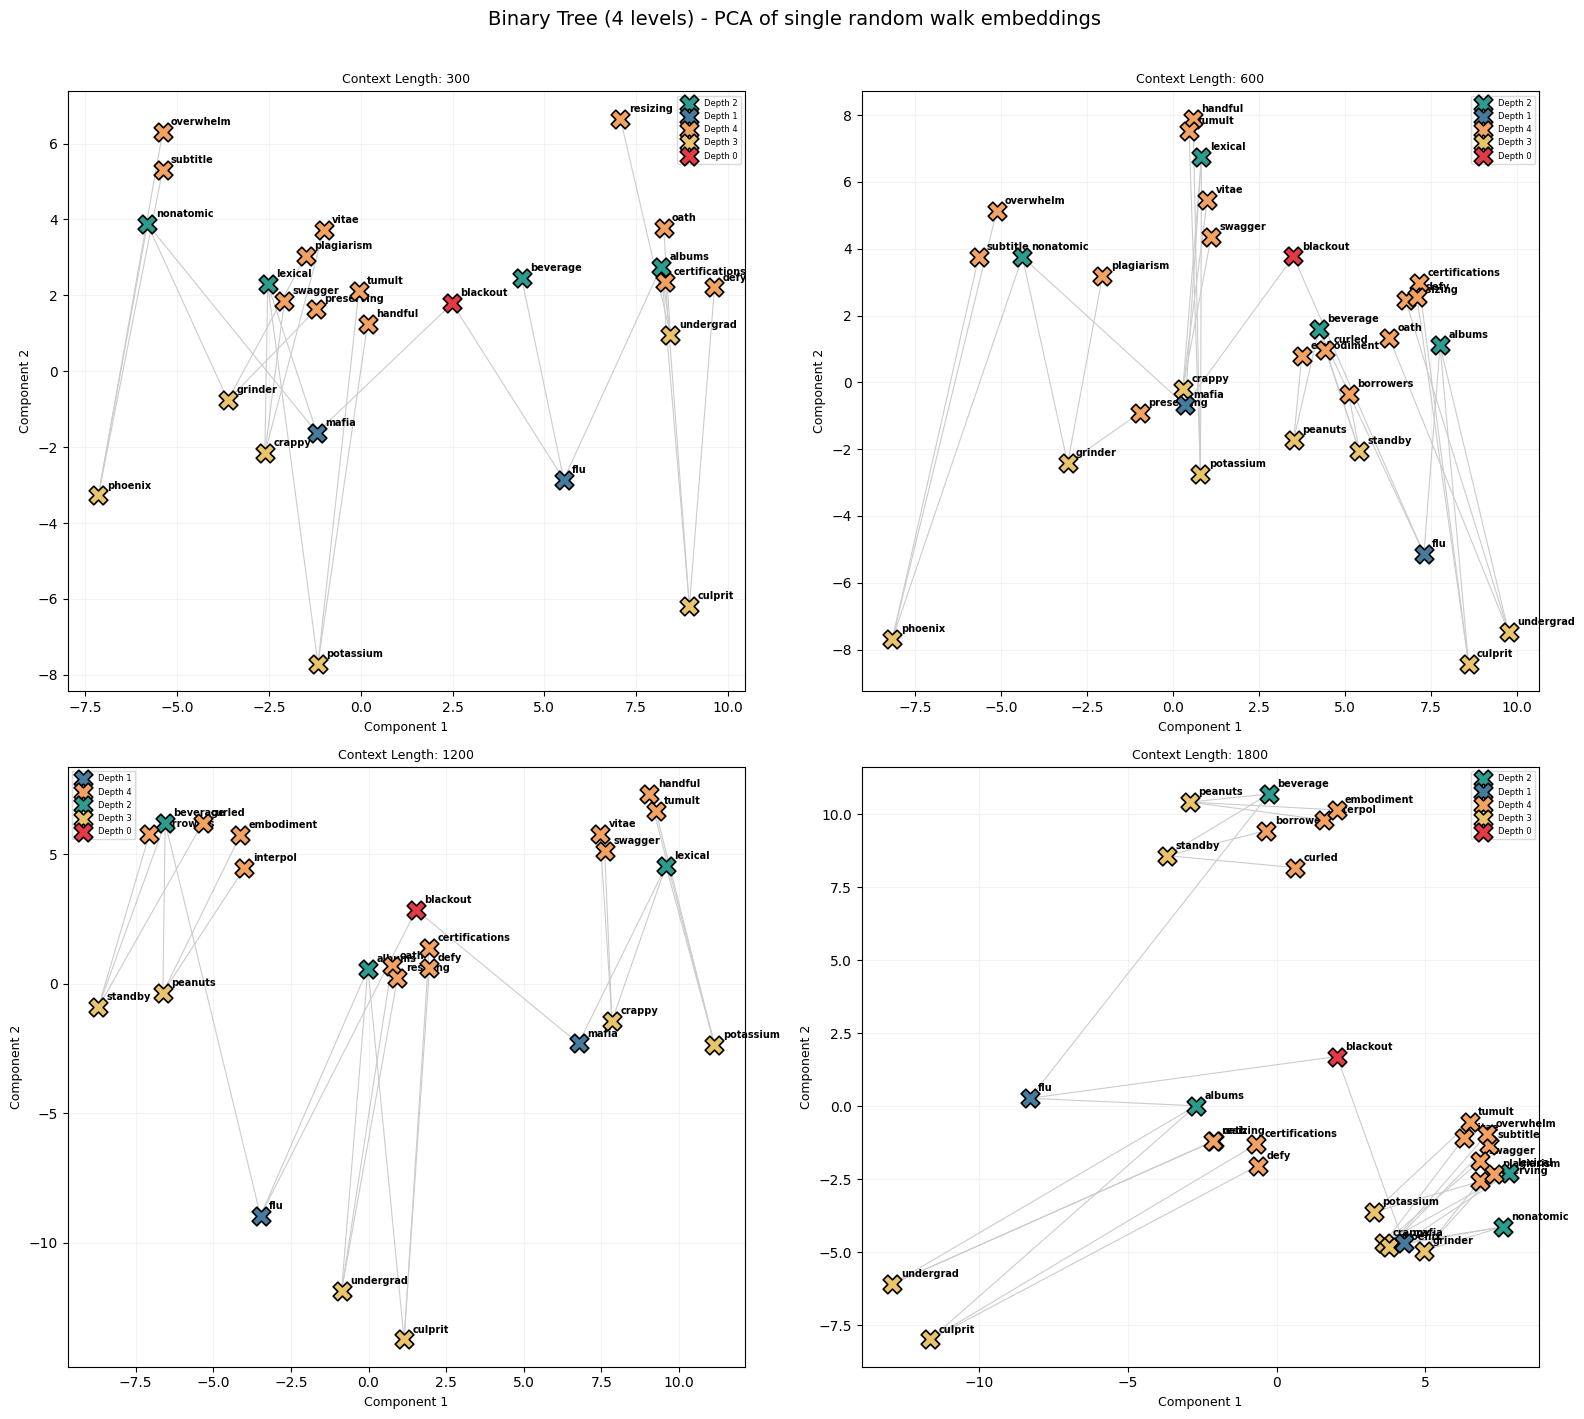

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_bin_tree_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Length: {ctx}", only_centroid=True)

fig.suptitle("Binary Tree (4 levels) - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### Dendrogram

Processing context length: 300
  [] Warning: token 'handful' has only 9 occurrences (requested 10)
  [] Warning: token 'plagiarism' has only 4 occurrences (requested 10)
  [] Warning: token 'certifications' has only 6 occurrences (requested 10)
  [] Warning: token 'oath' has only 7 occurrences (requested 10)
  [] Warning: token 'tumult' has only 9 occurrences (requested 10)
  [] Warning: token 'resizing' has only 7 occurrences (requested 10)
  [] Warning: token 'defy' has only 8 occurrences (requested 10)
  [] Warning: token 'subtitle' has only 8 occurrences (requested 10)
  [] Warning: token 'vitae' has only 2 occurrences (requested 10)
  [] Warning: token 'swagger' has only 8 occurrences (requested 10)
  [] Warning: token 'preserving' has only 2 occurrences (requested 10)
Processing context length: 600
  [] Warning: token 'certifications' has only 6 occurrences (requested 10)
  [] Warning: token 'oath' has only 6 occurrences (requested 10)
  [] Warning: token 'resizing' has only 7 oc

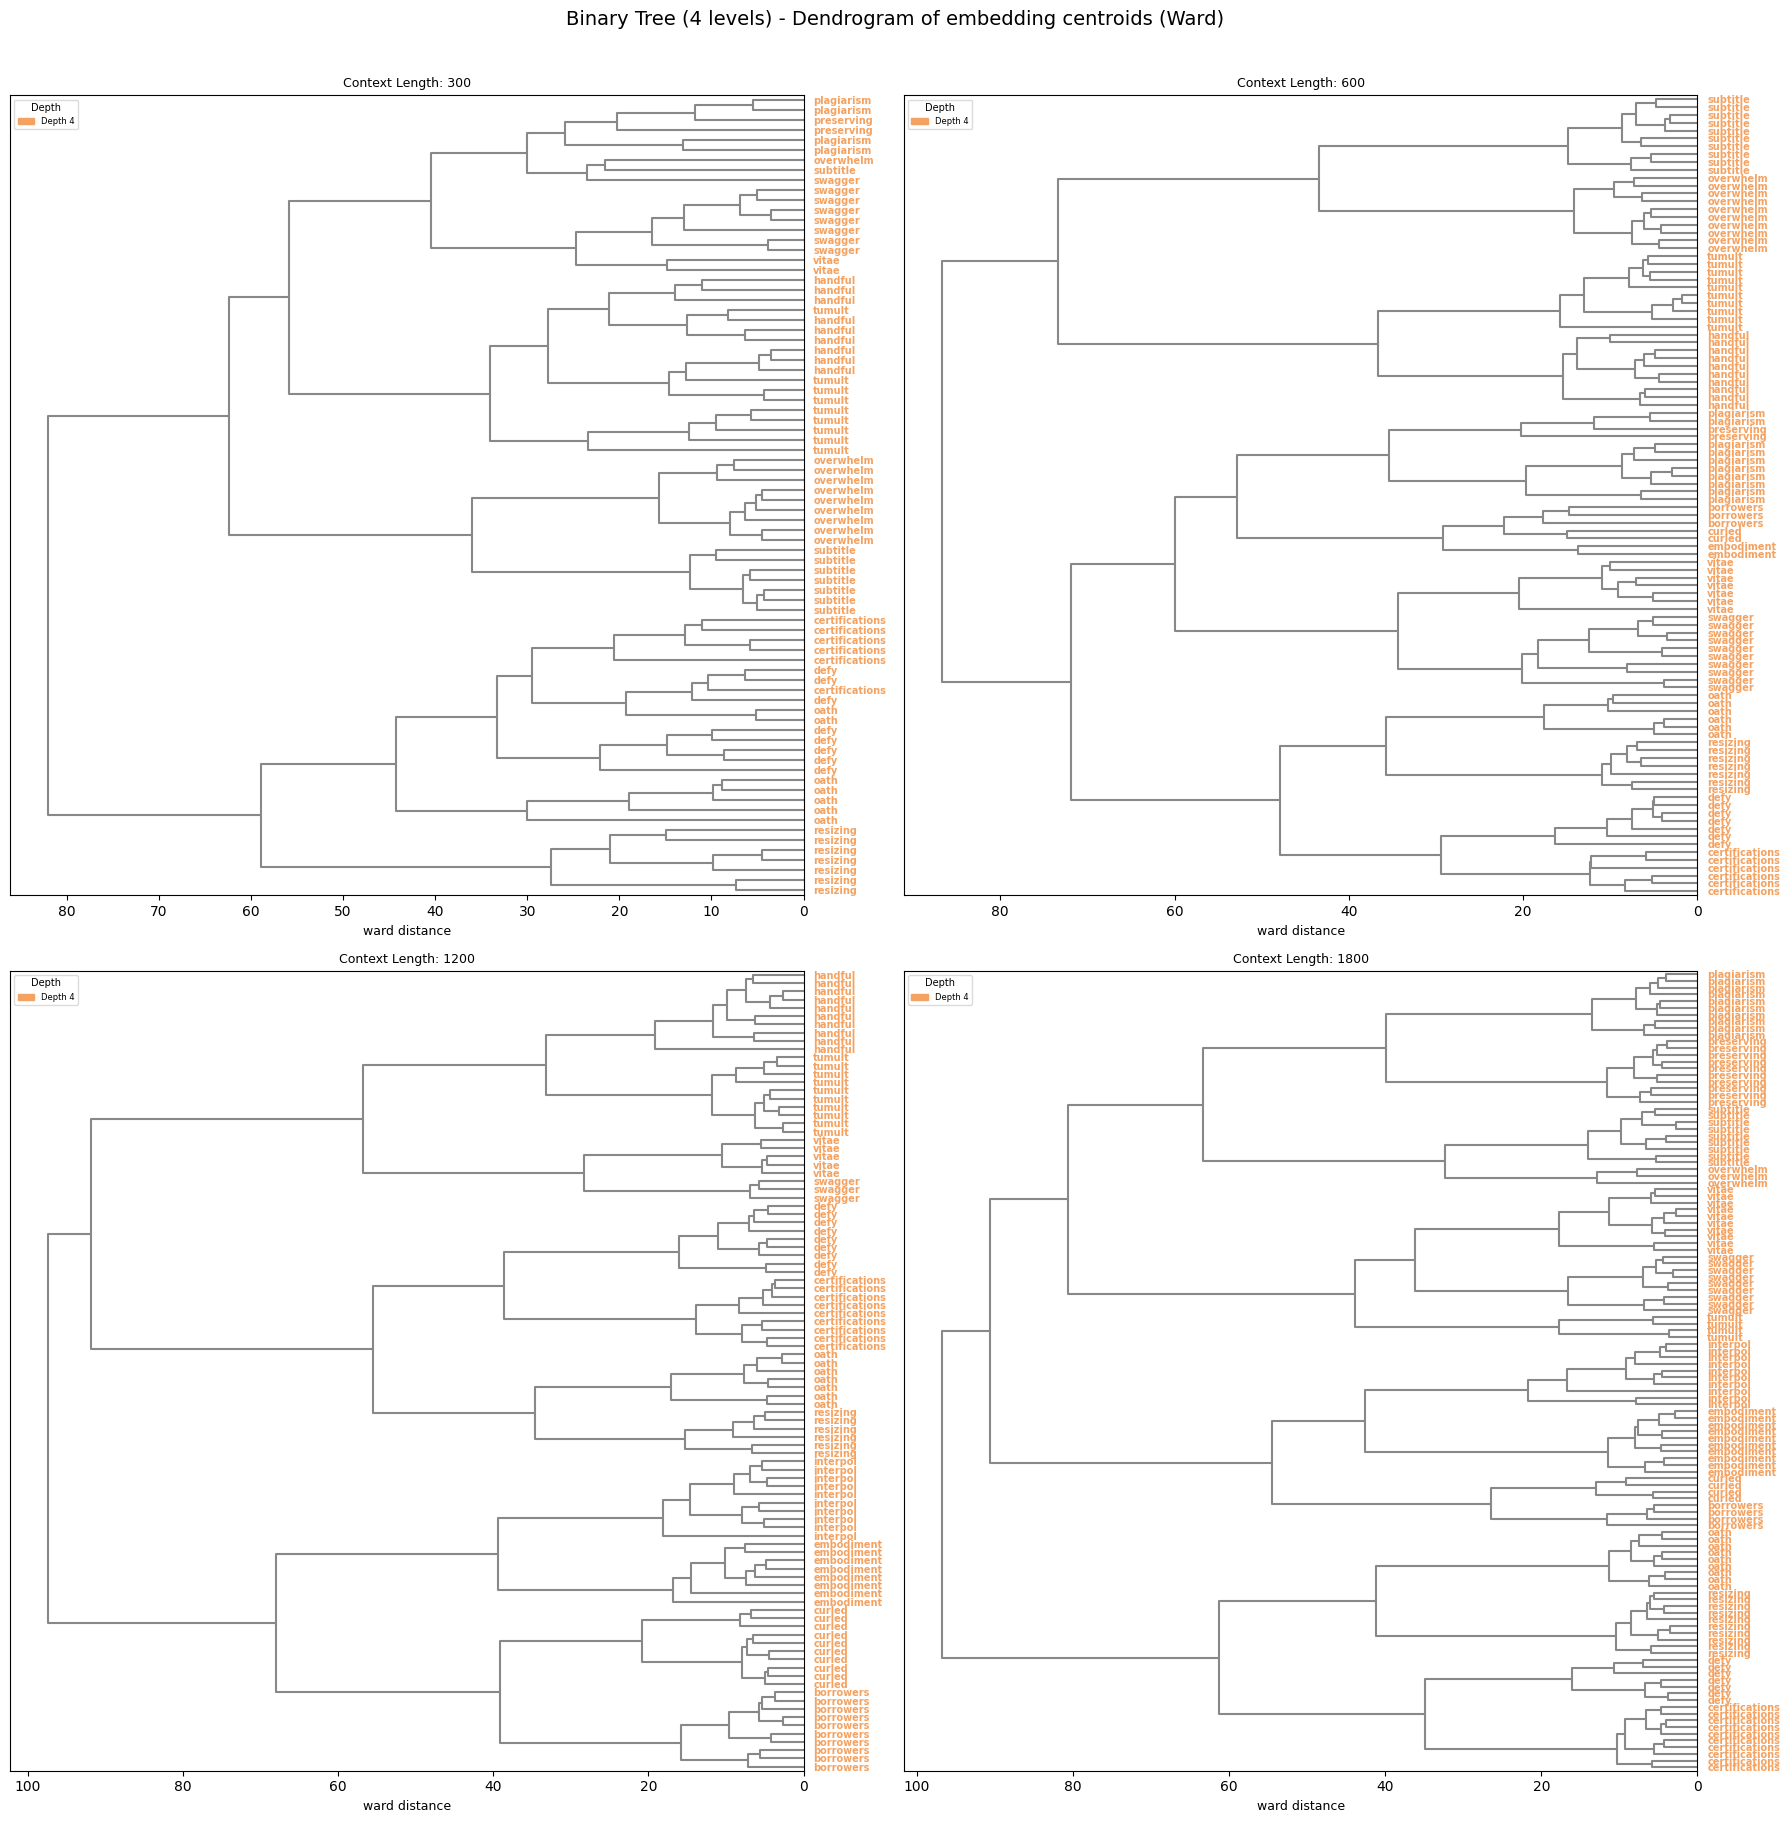

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 4

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, ctx in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {ctx}")
    pt_path = EMB_DIR / f"reprs_bin_tree_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    mask_layer_l = np.isin(ids_np, ids_layer_l)

    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=10)
    hp_tree.plot_dendrogram_on_points(ax, filtered_ids, filtered_embs, title=f"Context Length: {ctx}", method="ward", max_leaves=180)

fig.suptitle("Binary Tree (4 levels) - Dendrogram of embedding centroids (Ward)",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### UMAP 2D

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_bin_tree_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    
    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word)
    #umap 
    reducer = umap.UMAP(n_components=2, random_state=0, n_jobs=1, min_dist=0.1)
    umap_result = reducer.fit_transform(filtered_embs)
    hp_tree.plot_reduced_emb(ax, umap_result, filtered_ids, title=f"Context Length: {ctx}", only_centroid=False)
    

fig.suptitle("Binary Tree (4 levels) - UMAP of embedding centroids",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### UMAP 3D

In [ ]:
fig = plt.figure(figsize=(18, 16))

for i, ctx in enumerate(CTX_LENS, start=1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    pt_path = EMB_DIR / f"reprs_bin_tree_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    
    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word)
    reducer = umap.UMAP(n_components=3, random_state=42, n_jobs=1)
    umap_result = reducer.fit_transform(filtered_embs)
    hp_tree.plot_reduced_emb(ax, umap_result, filtered_ids, title=f"Context Length: {ctx}", only_centroid=True)

fig.suptitle("Binary Tree (4 levels) - UMAP of embedding centroids",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Days Tree (3 levels)

In [15]:
VOCAB_PATH  = Path("../data/days_tkid_map.txt")
STRUCT_PATH = Path("../data/one_random_walk/tree_days/bin_tree_structure.txt")
EMB_DIR     = Path("../embeddings/one_random_walk/tree_days")
hp_tree_das = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)


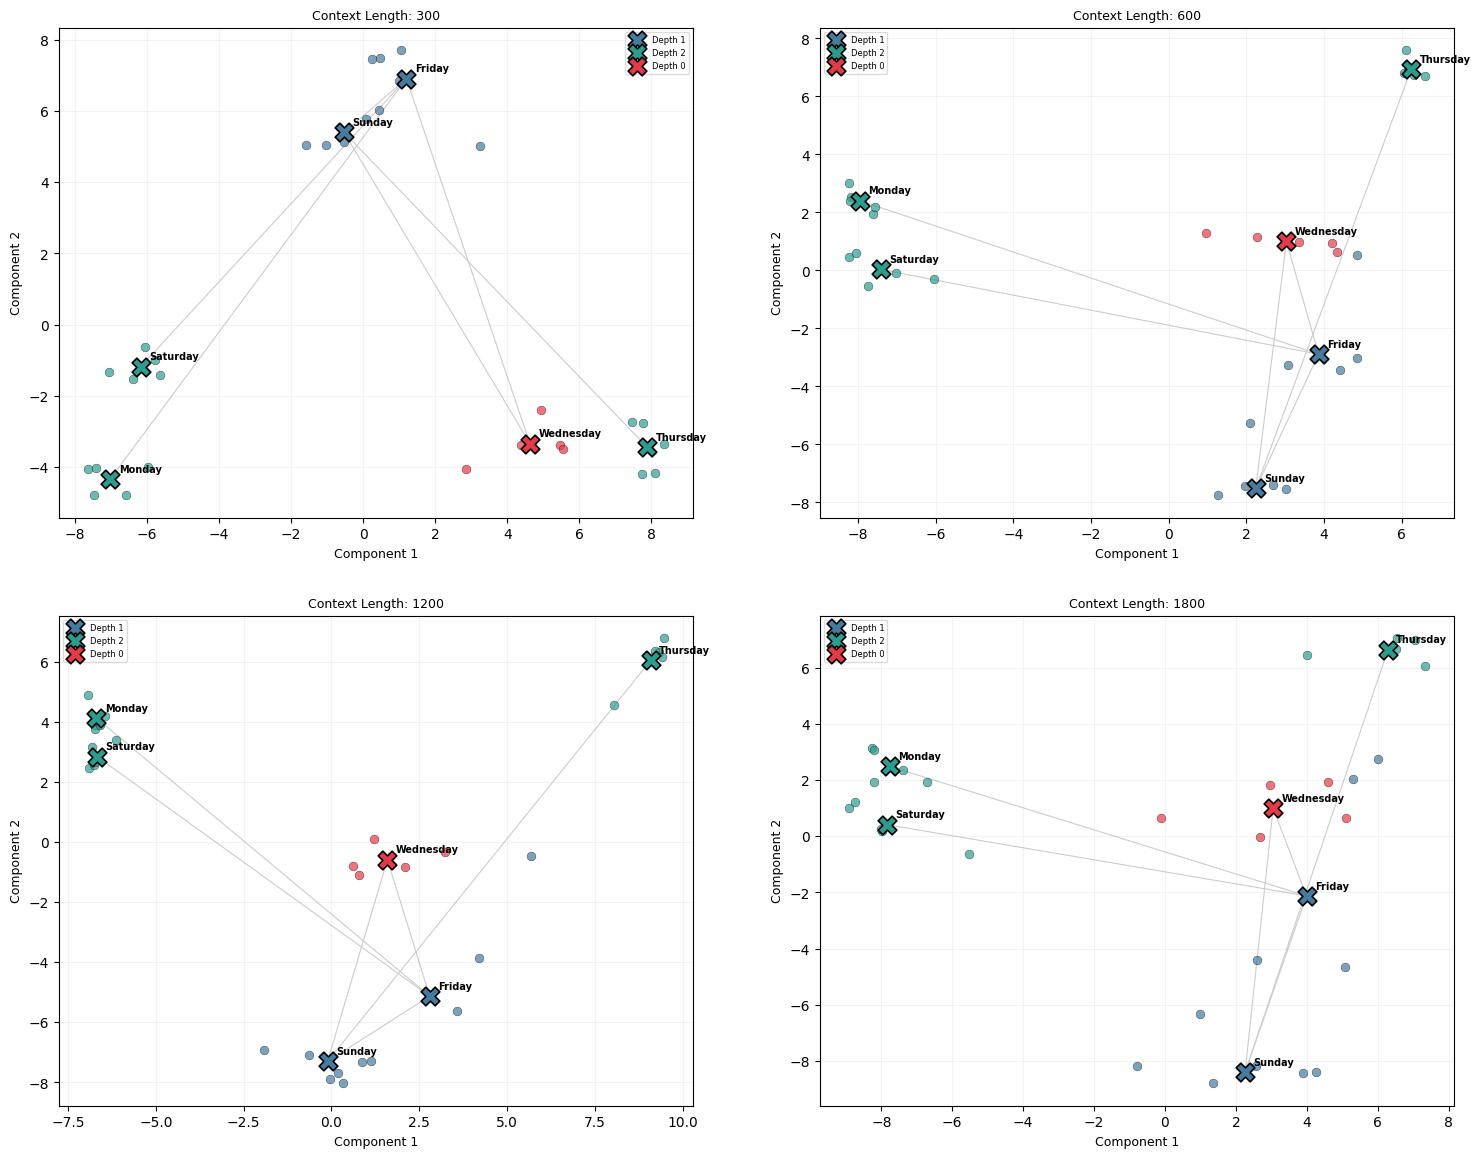

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_bin_tree_days_dataset_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    
    
    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree_das.id_to_word,k=5)
    reducer = PCA(n_components=2, random_state=42)
    pca_result = reducer.fit_transform(filtered_embs)
    hp_tree_das.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Length: {ctx}", only_centroid=False)

In [17]:
print(np.unique(ids_np))

[6740 7159 7418 7884 7950 8079]


## Cluster Tree (3 levels, 3 tokens/node)

In [ ]:
VOCAB_PATH  = Path("../data/uncorrelated-words/selected_llama31_layer0.txt")
STRUCT_PATH = Path("../data/one_random_walk/tree_clusters_3_levels/bin_tree_cluster_structure.txt")
EMB_DIR     = Path("../embeddings/one_random_walk/tree_clusters_3_levels")

hp_tree_cluster = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

### PCA 2D

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_bin_tree_cluster_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree_cluster.id_to_word)

    id_to_embs = {}
    for id, emb in zip(filtered_ids, filtered_embs):
        if id not in id_to_embs:
            id_to_embs[id] = []
        id_to_embs[id].append(emb)

    #compute centroids
    centroids = []
    filtered_ids_centroids = []
    for id, embs in id_to_embs.items():
        centroid = np.mean(embs, axis=0)
        centroids.append(centroid)
        filtered_ids_centroids.append(id)

    pca = PCA(n_components=2)
    reduced_emb = pca.fit_transform(centroids)

    hp_tree_cluster.plot_reduced_emb(ax, reduced_emb, filtered_ids_centroids, title=f"Cluster tree - ctx {ctx}")

fig.suptitle("Cluster Binary Tree (3 levels, 3 tokens/node) - PCA embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### Dendrogram

In [ ]:
layer = 3

toks_layer_l = [toks for toks, depth in hp_tree_cluster.token_to_group.items() if depth == layer]
ids_layer_l = [hp_tree_cluster.word_to_tid[tok] for tok in toks_layer_l]

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

for ax, ctx in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_bin_tree_cluster_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    mask_layer_l = np.isin(ids_np, ids_layer_l)

    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree_cluster.id_to_word)
    hp_tree_cluster.plot_dendrogram(ax, filtered_ids, filtered_embs, title=f"Cluster tree - ctx {ctx}", method="ward")

fig.suptitle("Cluster Binary Tree (3 levels, 3 tokens/node) - Dendrogram of embedding centroids (Ward)",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### UMAP 2D

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_bin_tree_cluster_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree_cluster.id_to_word)
    
    #compute the centroid for each id in filtered_ids of the filtered_embs
    id_to_embs = {}
    for id, emb in zip(filtered_ids, filtered_embs):
        if id not in id_to_embs:
            id_to_embs[id] = []
        id_to_embs[id].append(emb)

    #compute centroids
    centroids = []
    filtered_ids_centroids = []
    for id, embs in id_to_embs.items():
        centroid = np.mean(embs, axis=0)
        centroids.append(centroid)
        filtered_ids_centroids.append(id)

    #umap
    reducer = umap.UMAP(n_components=2, random_state=0, n_jobs=1, min_dist=0.1)
    umap_result = reducer.fit_transform(centroids)
    hp_tree_cluster.plot_reduced_emb(ax, umap_result, filtered_ids_centroids, title=f"Cluster tree - ctx {ctx}", only_centroid=True)

fig.suptitle("Cluster Binary Tree (3 levels, 3 tokens/node) - UMAP of embedding centroids",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### UMAP 3D

In [ ]:
fig = plt.figure(figsize=(18, 16))

for i, ctx in enumerate(CTX_LENS, start=1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    pt_path = EMB_DIR / f"reprs_bin_tree_cluster_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    plot_umap_on_ax(
        ax, ids_np, emb_np, ID_TO_WORD,
        token_to_depth, DEPTH_COLORS, depth_labels,
        all_edges, title=f"Cluster tree UMAP - ctx {ctx}",
        font_size=5, point_size=30, n_components=3,
    )

fig.suptitle("Cluster Binary Tree (3 levels, 3 tokens/node) - UMAP of embedding centroids",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()